**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 7 — Rolling returns

Retorno anualizado en ventanas móviles de 36 meses.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT/'src'))
import portfolio_utils as pu
daily = pd.read_csv(ROOT/'data'/'precios_ajustados_diarios.csv', index_col=0, parse_dates=True)
monthly = pu.to_month_end(daily).loc[:'2026-09-30']
bt = pu.backtest_portfolio(monthly, pu.CURRENT_WEIGHTS, start='2016-01-31', end='2026-09-30', rebalance='A')
spy = pu.backtest_portfolio(monthly, {'SPY':1}, start='2016-01-31', end='2026-09-30', rebalance='N')
win=36
roll_p = (1+bt['return']).rolling(win).apply(lambda x: x.prod()**(12/win)-1, raw=False)
roll_s = (1+spy['return']).rolling(win).apply(lambda x: x.prod()**(12/win)-1, raw=False)
print('Último rolling 36m portafolio:', round(100*float(roll_p.dropna().iloc[-1]), 2), '%')
print('Último rolling 36m SPY       :', round(100*float(roll_s.dropna().iloc[-1]), 2), '%')


Último rolling 36m portafolio: 26.8 %
Último rolling 36m SPY       : 20.1 %


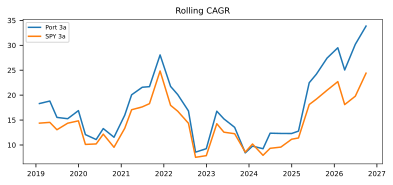

In [1]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(roll_p.index, roll_p*100, label='Portafolio')
ax.plot(roll_s.index, roll_s*100, label='SPY')
ax.set_ylabel('% anualizado'); ax.set_title('Rolling 36 meses'); ax.legend()
plt.tight_layout(); plt.show()


## Conclusiones
1. El outperformance no es uniforme; depende de la ventana.

## Ejercicios
1. Ventana 12m vs 60m.
2. % de ventanas con portafolio > SPY.
